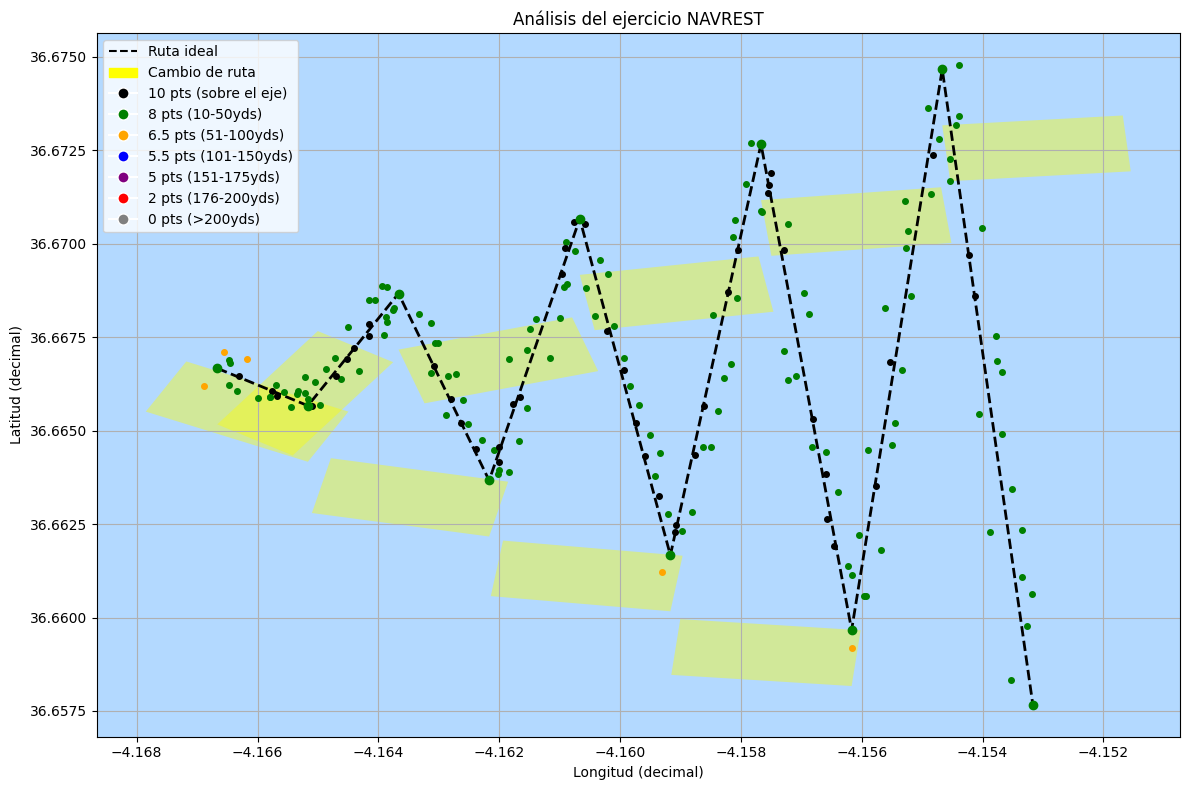


📝 Resultados del ejercicio NAVREST:
✅ Puntuación media por distancia al eje: 8.46 / 10

⏱️ Tiempos en Waypoints:
  - WP1: ✅ A tiempo (+-3.0s)
  - WP3: ⚠️ Se retrasó 9.0s
  - WP5: ✅ A tiempo (+0.0s)
  - WP7: ✅ A tiempo (+0.0s)
  - WP9: ✅ A tiempo (+0.0s)

🧭 Precisión en caídas de rumbo:
  - Caída 5: Error 75.0 yds → ⚠️ Dentro del límite

🚨 Maniobras especiales detectadas:
  - En t=45.0: Caída brusca por pérdida de control

🎨 Conteo de puntos por categoría de distancia:
  - black: 45 punto(s)
  - green: 130 punto(s)
  - orange: 5 punto(s)
  - blue: 0 punto(s)
  - purple: 0 punto(s)
  - red: 0 punto(s)
  - gray: 0 punto(s)


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import List, Tuple, Dict
import random
import math

def dms_to_decimal(deg: int, minutes: int, seconds: float) -> float:
    return deg + minutes / 60 + seconds / 3600

def decimal_to_dms(dec: float) -> str:
    d = int(dec)
    m = int(abs(dec - d) * 60)
    s = (abs(dec - d) * 60 - m) * 60
    return f"{abs(d)}° {m}′ {s:.2f}″ {'N' if dec >= 0 else 'S'}"

def deg_to_yards(distance_deg: float) -> float:
    return distance_deg * 111320 * 1.09361

def point_to_segment_distance(lat, lon, lat1, lon1, lat2, lon2) -> float:
    A = (lat1, lon1)
    B = (lat2, lon2)
    P = (lat, lon)

    AB = (B[0] - A[0], B[1] - A[1])
    AP = (P[0] - A[0], P[1] - A[1])

    ab_squared = AB[0]**2 + AB[1]**2
    if ab_squared == 0:
        return math.hypot(AP[0], AP[1])

    t = max(0, min(1, (AP[0]*AB[0] + AP[1]*AB[1]) / ab_squared))
    closest = (A[0] + t * AB[0], A[1] + t * AB[1])
    return math.hypot(P[0] - closest[0], P[1] - closest[1])

def simulate_realistic_route() -> List[Tuple[float, float, float]]:
    base_lat = dms_to_decimal(36, 40, 0)
    base_lon = dms_to_decimal(-5, 50, 0)

    route = []
    for i in range(10):
        lat = base_lat + (i * 0.001 * (-1 if i % 2 else 1))
        lon = base_lon + i * 0.0015
        t = i * 10
        route.append((lat, lon, t))
    return route

def simulate_navrest_example() -> Tuple[List[Tuple[float, float, float]], List[Tuple[float, float, float]], Dict[str, any]]:
    route = simulate_realistic_route()
    track = []
    major_events = []
    off_axis_behavior = []
    turn_accuracy = []
    waypoint_timing = []
    color_counts = {'black': 0, 'green': 0, 'orange': 0, 'blue': 0, 'purple': 0, 'red': 0, 'gray': 0}
    current_time = 0

    for i in range(len(route) - 1):
        lat1, lon1, t1 = route[i]
        lat2, lon2, t2 = route[i + 1]
        num_steps = 20
        for j in range(num_steps):
            alpha = j / num_steps
            lat_interp = lat1 + alpha * (lat2 - lat1)
            lon_interp = lon1 + alpha * (lon2 - lon1)
            lat_dev = lat_interp + random.uniform(-0.0005, 0.0005)
            lon_dev = lon_interp + random.uniform(-0.0003, 0.0003)
            t = current_time + j * ((t2 - t1) / num_steps)
            track.append((lat_dev, lon_dev, t))
        current_time += (t2 - t1)

    major_events.append((track[len(track)//2][2], "Caída brusca por pérdida de control"))
    turn_accuracy.append(("5", random.randint(20, 200)))

    for i in range(1, len(route), 2):
        expected_time = route[i][2]
        actual_time = expected_time + random.choice([-10, -3, 0, 4, 9])
        waypoint_timing.append((str(i), actual_time - expected_time))

    results = {
        "avg_distance_score": round(random.uniform(5.5, 9.5), 2),
        "major_events": major_events,
        "turn_accuracy": turn_accuracy,
        "waypoint_timing": waypoint_timing,
        "color_counts": color_counts
    }

    return track, route, results

def calculate_average_score(color_counts: Dict[str, int]) -> float:
    # Definir los valores de puntuación asociados a cada categoría
    score_map = {
        'black': 10,
        'green': 8,
        'orange': 6.5,
        'blue': 5.5,
        'purple': 5,
        'red': 2,
        'gray': 0
    }

    # Calcular la puntuación total ponderada
    total_score = 0
    total_points = 0
    for color, count in color_counts.items():
        total_score += score_map[color] * count
        total_points += count

    # Evitar división por cero si no hay puntos
    if total_points == 0:
        return 0.0

    # Promedio ponderado de la puntuación
    return total_score / total_points

def plot_navrest_analysis(track: List[Tuple[float, float, float]],
                          route: List[Tuple[float, float, float]],
                          results: Dict[str, any]):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_facecolor('#b3d9ff')

    route_lat = [p[0] for p in route]
    route_lon = [p[1] for p in route]
    ax.plot(route_lon, route_lat, 'k--', label="Ruta ideal", linewidth=2)
    ax.scatter(route_lon, route_lat, color='green', zorder=5)

    for i in range(len(route) - 1):
        lat1, lon1, _ = route[i]
        lat2, lon2, _ = route[i + 1]
        dx = lon2 - lon1
        dy = lat2 - lat1
        length = math.hypot(dx, dy)
        angle = math.degrees(math.atan2(dy, dx))
        width = 0.003
        rect = patches.Rectangle((lon1, lat1 - 0.0015),
                                 dx if dx else 0.00001,
                                 width,
                                 angle=angle,
                                 linewidth=0,
                                 facecolor='yellow',  # Cambio de color
                                 alpha=0.4,
                                 transform=ax.transData)
        ax.add_patch(rect)

    color_legend = {
        'black': '10 pts (sobre el eje)',
        'green': '8 pts (10-50yds)',
        'orange': '6.5 pts (51-100yds)',
        'blue': '5.5 pts (101-150yds)',
        'purple': '5 pts (151-175yds)',
        'red': '2 pts (176-200yds)',
        'gray': '0 pts (>200yds)'
    }

    legend_handles = {k: plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=k, markersize=8, label=v)
                      for k, v in color_legend.items()}

    for lat, lon, t in track:
        min_dist = float('inf')
        for i in range(len(route) - 1):
            lat1, lon1, _ = route[i]
            lat2, lon2, _ = route[i + 1]
            dist = point_to_segment_distance(lat, lon, lat1, lon1, lat2, lon2)
            min_dist = min(min_dist, dist)

        dist_yds = deg_to_yards(min_dist)
        if dist_yds <= 10:
            color = 'black'
        elif dist_yds <= 50:
            color = 'green'
        elif dist_yds <= 100:
            color = 'orange'
        elif dist_yds <= 150:
            color = 'blue'
        elif dist_yds <= 175:
            color = 'purple'
        elif dist_yds <= 200:
            color = 'red'
        else:
            color = 'gray'

        results["color_counts"][color] += 1
        ax.plot(lon, lat, marker='o', markersize=4, color=color)

    legend_elements = [plt.Line2D([0], [0], linestyle='--', color='black', label='Ruta ideal'),
                       patches.Patch(color='yellow', label='Cambio de ruta')]
    legend_elements.extend(legend_handles.values())

    ax.legend(handles=legend_elements)
    ax.set_xlabel("Longitud (decimal)")
    ax.set_ylabel("Latitud (decimal)")
    ax.set_title("Análisis del ejercicio NAVREST")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Ejecutar
track_data, route_data, resultados = simulate_navrest_example()
plot_navrest_analysis(track_data, route_data, resultados)

# Calcular la puntuación media
average_score = calculate_average_score(resultados["color_counts"])
resultados["avg_distance_score"] = round(average_score, 2)

# Mostrar resultados
print("\n📝 Resultados del ejercicio NAVREST:")
print(f"✅ Puntuación media por distancia al eje: {resultados['avg_distance_score']} / 10\n")

if resultados["waypoint_timing"]:
    print("⏱️ Tiempos en Waypoints:")
    for wp_id, delta in resultados["waypoint_timing"]:
        if delta is None:
            status = "No pasó por el waypoint"
        elif abs(delta) < 5:
            status = f"✅ A tiempo (+{delta:.1f}s)"
        elif delta < 0:
            status = f"⚠️ Se adelantó {abs(delta):.1f}s"
        else:
            status = f"⚠️ Se retrasó {delta:.1f}s"
        print(f"  - WP{wp_id}: {status}")

if resultados["turn_accuracy"]:
    print("\n🧭 Precisión en caídas de rumbo:")
    for turn_id, error in resultados["turn_accuracy"]:
        if error < 50:
            status = "✅ Precisa"
        elif error <= 150:
            status = "⚠️ Dentro del límite"
        else:
            status = "❌ Fuera de la canal"
        print(f"  - Caída {turn_id}: Error {error:.1f} yds → {status}")

if resultados["major_events"]:
    print("\n🚨 Maniobras especiales detectadas:")
    for timestamp, desc in resultados["major_events"]:
        print(f"  - En t={timestamp}: {desc}")

# Mostrar conteo de puntos por categoría
print("\n🎨 Conteo de puntos por categoría de distancia:")
for color, count in resultados["color_counts"].items():
    print(f"  - {color}: {count} punto(s)")
